In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('stocks (1).csv')
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


### Task 1: Initial Data Loading and Inspection

In [3]:
print("DataFrame Head:")
print(df.head())

DataFrame Head:
  Ticker        Date        Open        High         Low       Close  \
0   AAPL  2023-02-07  150.639999  155.229996  150.639999  154.649994   
1   AAPL  2023-02-08  153.880005  154.580002  151.169998  151.919998   
2   AAPL  2023-02-09  153.779999  154.330002  150.419998  150.869995   
3   AAPL  2023-02-10  149.460007  151.339996  149.220001  151.009995   
4   AAPL  2023-02-13  150.949997  154.259995  150.919998  153.850006   

    Adj Close    Volume  
0  154.414230  83322600  
1  151.688400  64120100  
2  150.639999  56007100  
3  151.009995  57450700  
4  153.850006  62199000  


In [4]:
print("Data Shape:")
print(df.shape)

Data Shape:
(248, 8)


In [5]:
print("Duplicated Data Count:")
print(f'Number of duplicated data: {df.duplicated().sum()}')

Duplicated Data Count:
Number of duplicated data: 0


In [6]:
print("Missing Values (Percentage):")
print((df.isnull().sum() / len(df)) * 100)

Missing Values (Percentage):
Ticker       0.0
Date         0.0
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
dtype: float64


In [7]:
print("Data Types:")
print(df.dtypes)

Data Types:
Ticker        object
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [8]:
print("Data Description:")
print(df.describe())

Data Description:
             Open        High         Low       Close   Adj Close  \
count  248.000000  248.000000  248.000000  248.000000  248.000000   
mean   215.252093  217.919662  212.697452  215.381674  215.362697   
std     91.691315   92.863023   90.147881   91.461989   91.454750   
min     89.540001   90.129997   88.860001   89.349998   89.349998   
25%    135.235004  137.440004  134.822495  136.347498  136.347498   
50%    208.764999  212.614998  208.184998  209.920006  209.920006   
75%    304.177505  307.565002  295.437500  303.942505  303.942505   
max    372.410004  373.829987  361.739990  366.829987  366.829987   

             Volume  
count  2.480000e+02  
mean   3.208210e+07  
std    2.233590e+07  
min    2.657900e+06  
25%    1.714180e+07  
50%    2.734000e+07  
75%    4.771772e+07  
max    1.133164e+08  


### Task 2: Date Column Conversion

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print("\nDataFrame Head after Date conversion and setting as index:")
print(df.head())


DataFrame Head after Date conversion and setting as index:
           Ticker        Open        High         Low       Close   Adj Close  \
Date                                                                            
2023-02-07   AAPL  150.639999  155.229996  150.639999  154.649994  154.414230   
2023-02-08   AAPL  153.880005  154.580002  151.169998  151.919998  151.688400   
2023-02-09   AAPL  153.779999  154.330002  150.419998  150.869995  150.639999   
2023-02-10   AAPL  149.460007  151.339996  149.220001  151.009995  151.009995   
2023-02-13   AAPL  150.949997  154.259995  150.919998  153.850006  153.850006   

              Volume  
Date                  
2023-02-07  83322600  
2023-02-08  64120100  
2023-02-09  56007100  
2023-02-10  57450700  
2023-02-13  62199000  


### Task 3: Analyze Trends

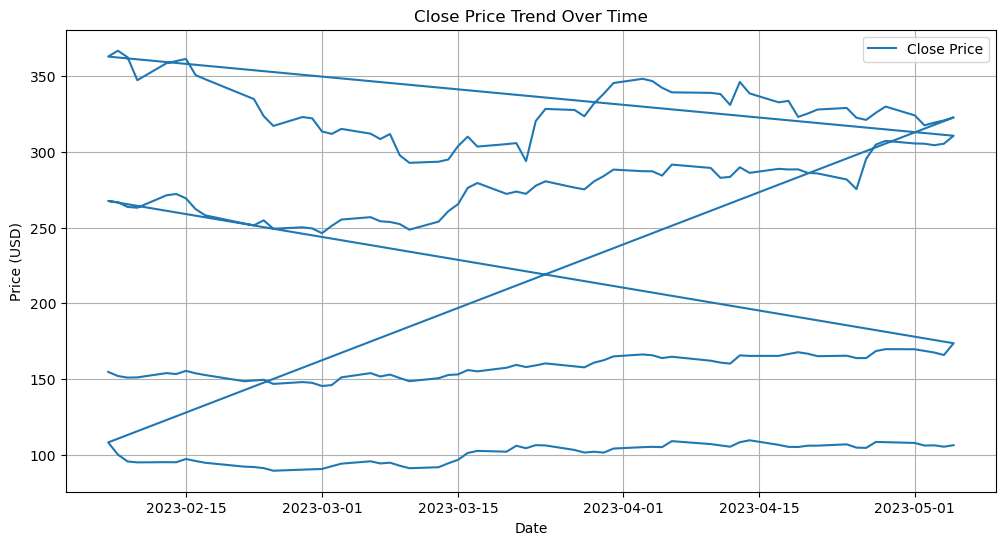

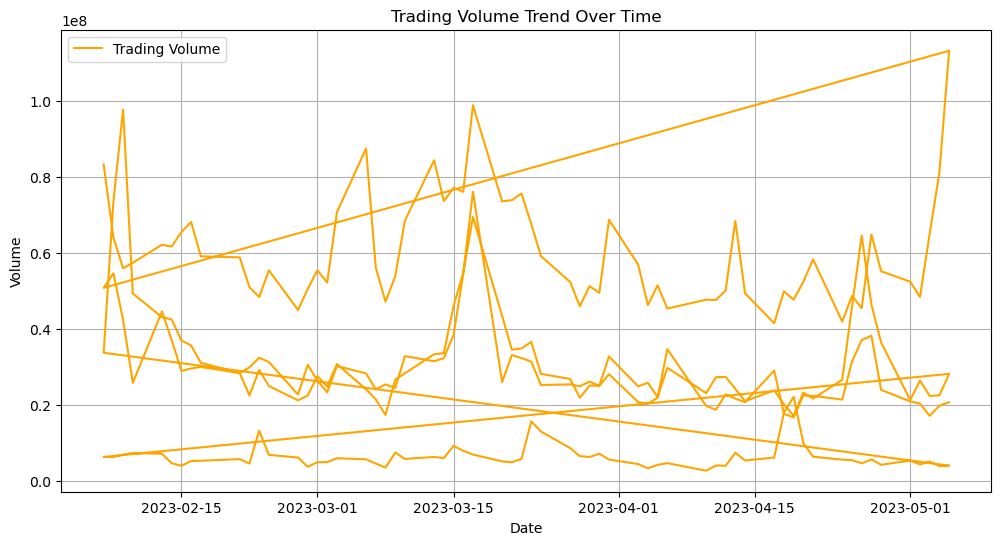

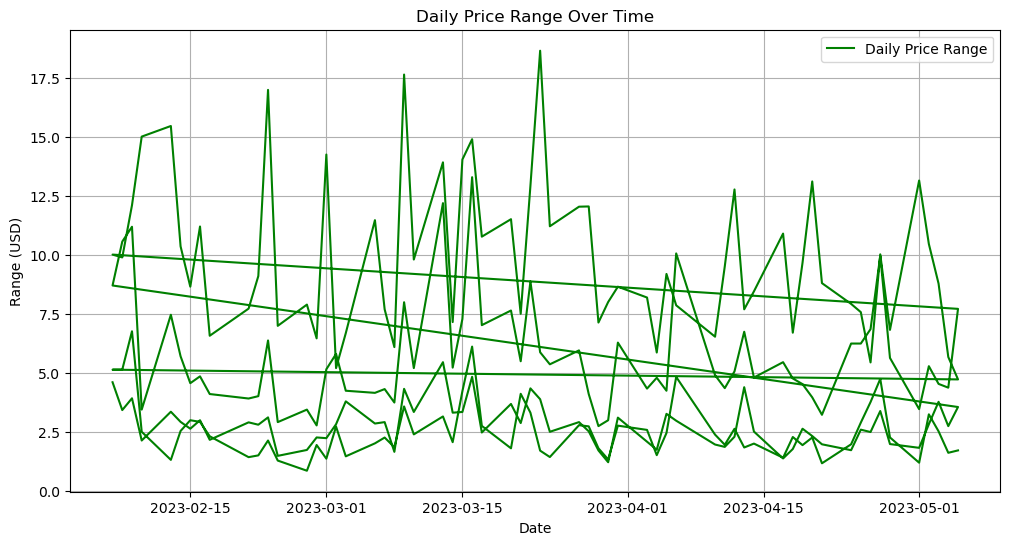

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price')
plt.title('Close Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label='Trading Volume', color='orange')
plt.title('Trading Volume Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

df['Daily_Range'] = df['High'] - df['Low']
plt.figure(figsize=(12, 6))
plt.plot(df['Daily_Range'], label='Daily Price Range', color='green')
plt.title('Daily Price Range Over Time')
plt.xlabel('Date')
plt.ylabel('Range (USD)')
plt.legend()
plt.grid(True)
plt.show()

### Task 4: Moving Averages

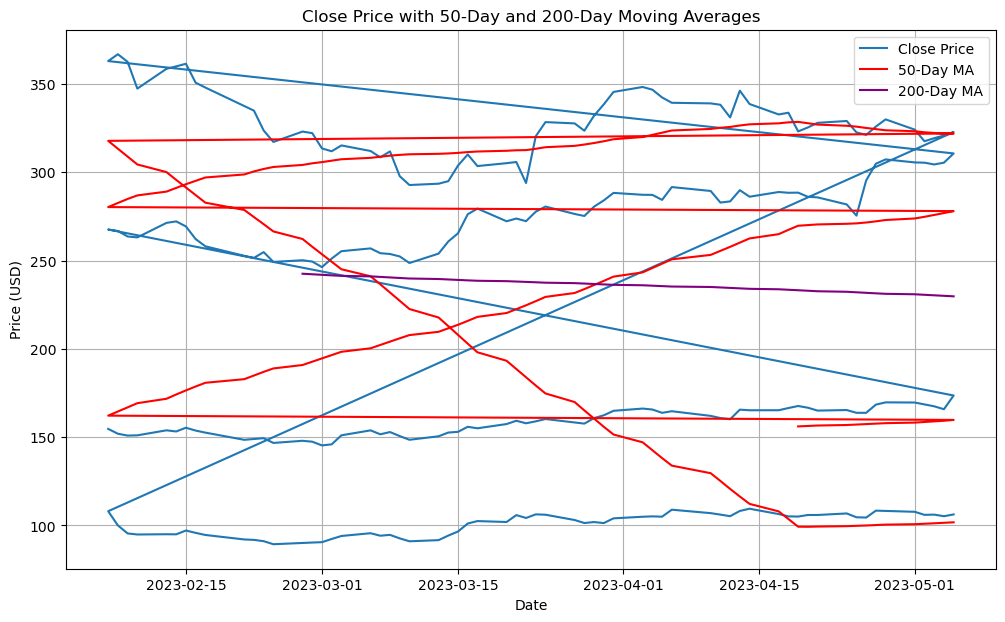

In [11]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()
plt.figure(figsize=(12, 7))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_50'], label='50-Day MA', color='red')
plt.plot(df['MA_200'], label='200-Day MA', color='purple')
plt.title('Close Price with 50-Day and 200-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### Task 5: Daily Returns

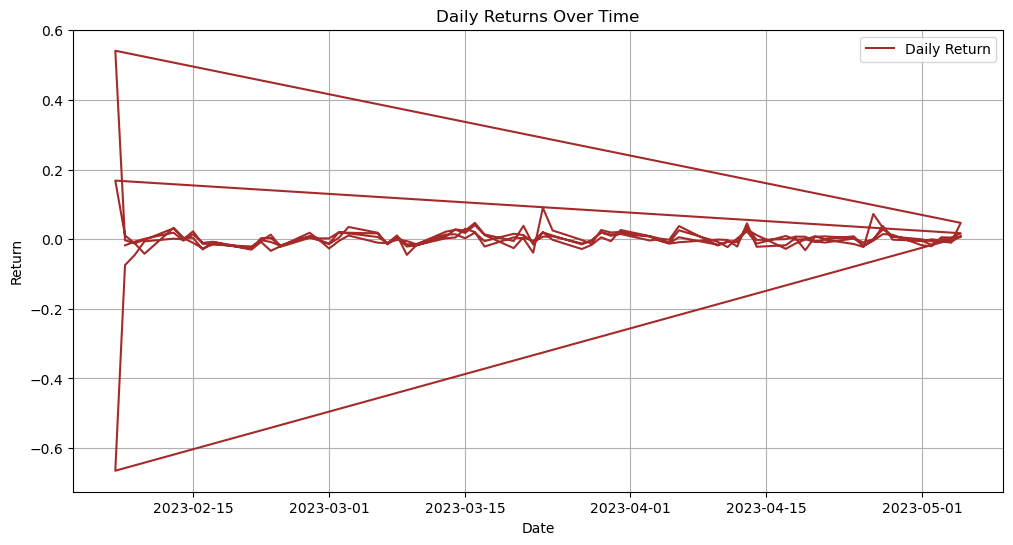

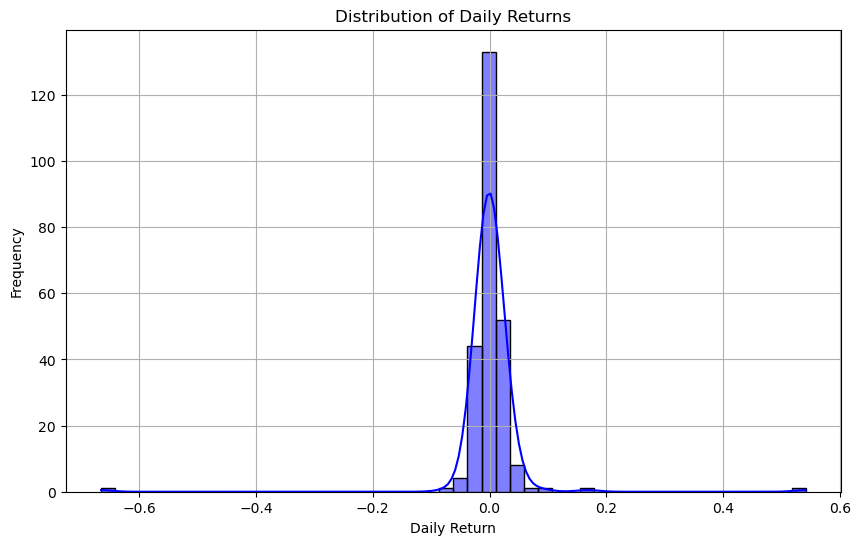

In [12]:
df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(12, 6))
plt.plot(df['Daily_Return'], label='Daily Return', color='brown')
plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Task 6: Volatility

In [13]:
volatility = df['Daily_Return'].std() * np.sqrt(252)
print(f'Annualized Volatility: {volatility:.2f}')

Annualized Volatility: 0.93


### Task 7: Correlation Matrix

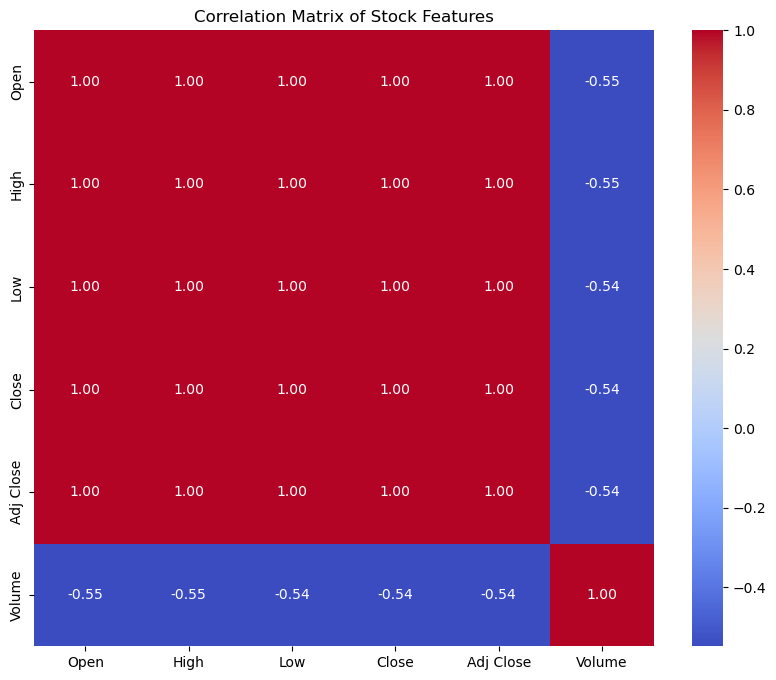

In [14]:
correlation_matrix = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Features')
plt.show()

### Task 8: Stock Price Forecasting - Data Preparation

In [15]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Task 9: Model Evaluation

Mean Squared Error: 2.28
R-squared: 1.00


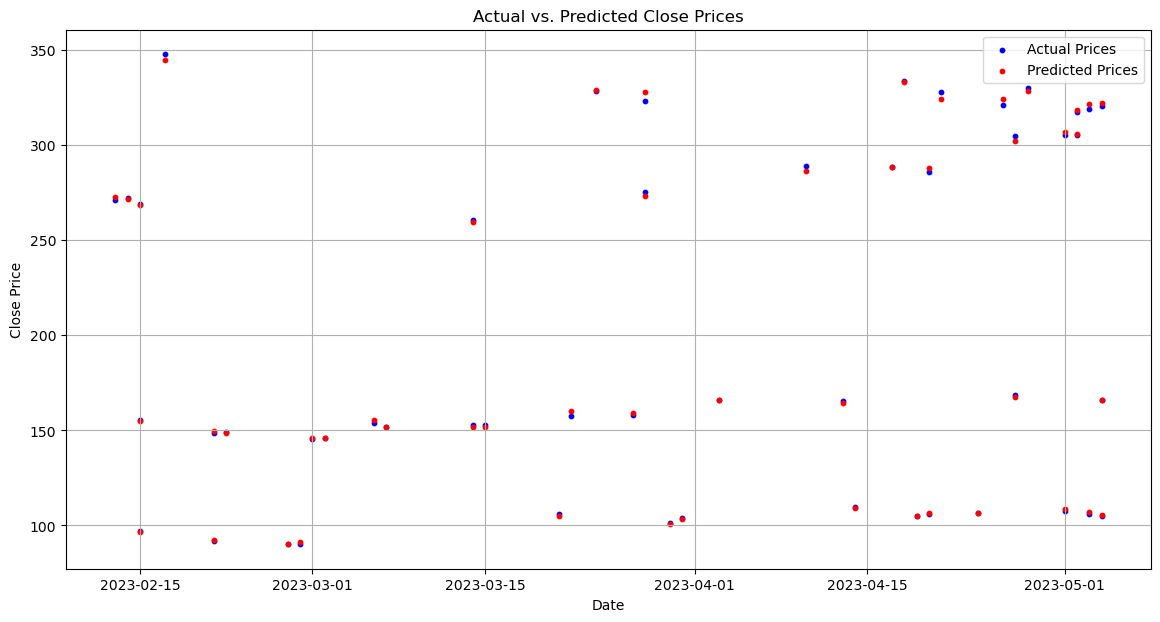

In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

plt.figure(figsize=(14, 7))
plt.scatter(y_test.index, y_test, color='blue', label='Actual Prices', s=10)
plt.scatter(y_test.index, y_pred, color='red', label='Predicted Prices', s=10)
plt.title('Actual vs. Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Task 10: Trading Strategy Development - Simple Moving Average Crossover Strategy

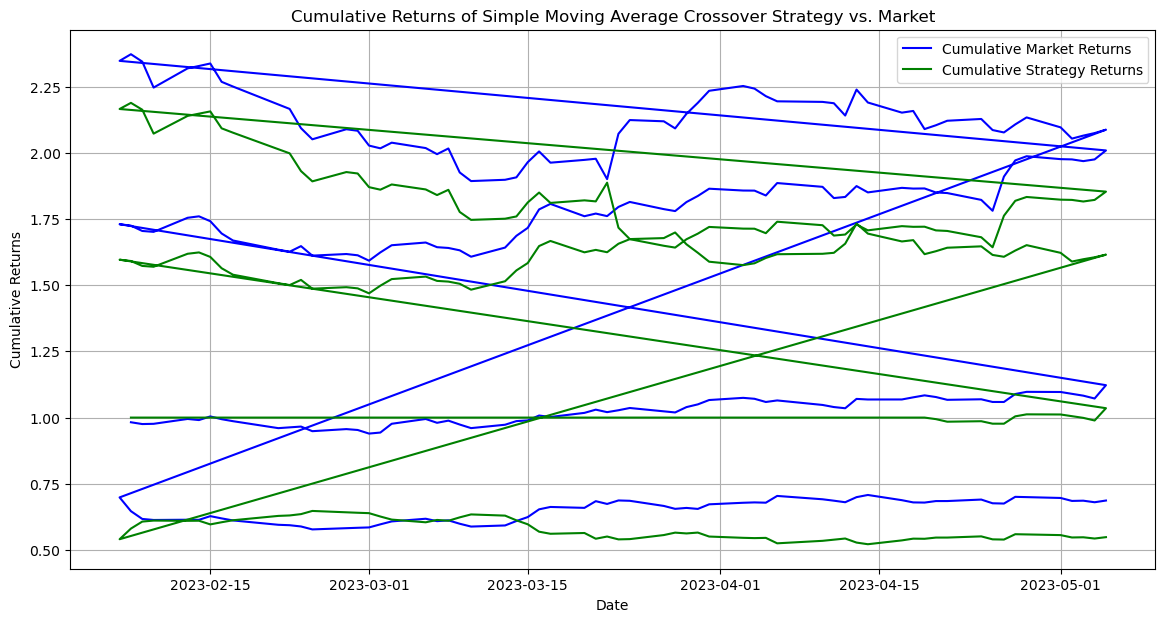

In [17]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

df['Signal'] = 0.0
df['Signal'][df['SMA_20'] > df['SMA_50']] = 1.0
df['Signal'][df['SMA_20'] < df['SMA_50']] = -1.0

df['Strategy_Returns'] = df['Daily_Return'] * df['Signal'].shift(1)

df['Cumulative_Market_Returns'] = (1 + df['Daily_Return']).cumprod()
df['Cumulative_Strategy_Returns'] = (1 + df['Strategy_Returns']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df['Cumulative_Market_Returns'], label='Cumulative Market Returns', color='blue')
plt.plot(df['Cumulative_Strategy_Returns'], label='Cumulative Strategy Returns', color='green')
plt.title('Cumulative Returns of Simple Moving Average Crossover Strategy vs. Market')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

### Task 11: Backtesting Metrics

In [18]:
total_strategy_return = (df['Cumulative_Strategy_Returns'].dropna().iloc[-1] - 1) if not df['Cumulative_Strategy_Returns'].dropna().empty else 0
total_market_return = (df['Cumulative_Market_Returns'].dropna().iloc[-1] - 1) if not df['Cumulative_Market_Returns'].dropna().empty else 0

In [19]:
print(f'Total Strategy Return: {total_strategy_return:.2f}')
print(f'Total Market Return: {total_market_return:.2f}')

Total Strategy Return: -0.45
Total Market Return: -0.31
